# Discrete Filters
Linear discrete filters can be divided into two groups: FIR and IIR filters, which will both be explained in the following.

## Finite Impulse Response Filters
Finite impulse response filters (FIR) can be used for applying a lowpass (LP), a bandpass (BP) or a highpass (HP) to an input signal $x(n)$. The FIR filter is defined by its impulse response $h(n)$. The output $y(n)$ of the FIR filter can be evaluated by convolution:

$y(n) = x(n)*h(n)=\sum_{m=0}^{M-1} h(m)\cdot x(n-m)$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
sys.path.insert(1, '../Basics')
import WaveFileHandling

r = 48000

x = np.arange(1000)
h = np.arange(100)**0.99
t1 = time.time()
y1 = np.convolve(x, h)
t2 = time.time()
print('Convolution with np.convolve took {:.6f} seconds'.format(t2 - t1))
t1 = time.time()
y2 = np.zeros((x.shape[0] + h.shape[0] - 1,))
for n in range(y2.shape[0]):
    for m in range(h.shape[0]):
        if (n-m >= 0) and (n-m < x.shape[0]):
            y2[n] += x[n-m] * h[m]
t2 = time.time()
print('Convolution with nested loops took {:.6f} seconds'.format(t2 - t1))
assert np.allclose(y1, y2), 'The results from both methods should be the same'

Convolution with np.convolve took 0.000135 seconds
Convolution with nested loops took 0.079572 seconds


## FIR: Fast convolution by DFT
The convolution in time domain corresponds to a multiplication in frequency domain:

$y(t)=h(t)*x(t) \iff Y(f)=H(f)\cdot X(f)$ with the Fourier transform defined by

$Y(f)=\int_{-\infty}^\infty y(t)\cdot e^{-j2\pi ft} dt$ for all three signals/impulse responses $y(t)$, $x(t)$ and $h(t)$.

A multiplication is much faster than the nested loops necessary for evaluation the convolution. Therefore, an algorithm will be introduced to evaluate the result of the convolution by the [DFT](../Week03_DiscreteFourierTransform/01_DiscreteFourierTransform.ipynb):

In [2]:
H = np.fft.fft(h, n=y1.shape[0])
X = np.fft.fft(x, n=y1.shape[0])
Y3 = H * X
y3 = np.fft.ifft(Y3).real
assert np.allclose(y1, y3), 'The results from both methods should be the same'

## FIR: Lowpass
A simple lowpass filter with cutoff frequency $f_c$ is defined by:

$h_\text{lowpass}(n)=\frac{\sin\left(2\pi f_c n/r\right)}{2\pi f_c n/r}\cdot w(n)$

with the Hann window

$w(n)=\frac{1}{2}\left(1+\cos\left(2\pi n / N \right)\right)\cdot\text{rect}\left(\frac{n}{N}\right)$.

The Hann window is restricted to the range $-\frac{N}{2}< n < \frac{N}{2}$ by the rect-Signal:

$\text{rect}(t)= 
\begin{cases}
    1,& \text{if } -0.5<t<0.5\\
    0,& \text{otherwise}
\end{cases}
$

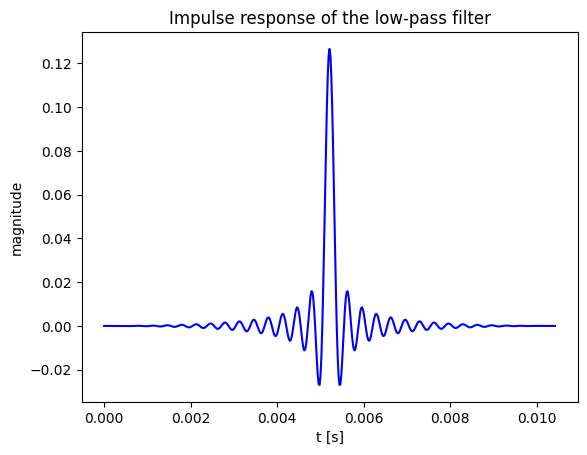

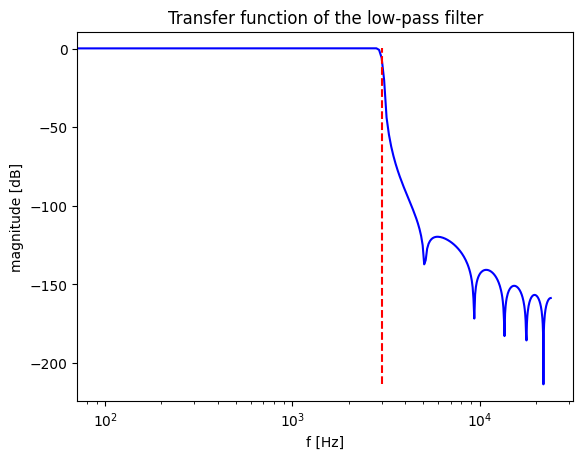

In [3]:
def EvalImpulseResponseOfLowpassFilter(fc, r, LengthOfFilterInSamples=501):
    assert fc < r/2, 'violation of sampling theorem'
    LengthOfFilterInSamples = 501
    n = np.arange(LengthOfFilterInSamples) - np.floor(LengthOfFilterInSamples / 2)
    t = n / r
    h_LP = np.sinc(2 * fc * t)
    w = 0.5 * (1 + np.cos(2 * np.pi * n / LengthOfFilterInSamples)) # Hann-Window
    h = w * h_LP
    h /= np.sum(h**2)
    return h

CutoffFrequency = 3000
h_LP = EvalImpulseResponseOfLowpassFilter(CutoffFrequency, r, 51)
t = np.arange(h_LP.shape[0]) / r
plt.plot(t, h_LP, 'b')
plt.xlabel('t [s]')
plt.ylabel('magnitude')
plt.title('Impulse response of the low-pass filter')
plt.show()

FFTLength = 2**int(np.ceil(np.log2(h_LP.shape[0])))
H_LP = np.fft.rfft(h_LP, n = FFTLength)
f = np.arange(H_LP.shape[0]) / FFTLength * r
H_LP_dB = 20 * np.log10(np.abs(H_LP))
plt.semilogx(f, H_LP_dB, 'b')
plt.plot([CutoffFrequency, CutoffFrequency], [H_LP_dB.min(), H_LP_dB.max()], 'r--')
plt.xlabel('f [Hz]')
plt.ylabel('magnitude [dB]')
plt.title('Transfer function of the low-pass filter')
plt.show()

## FIR: Bandpass
Each lowpass filter with cutoff frequency $f_c$ can be transformed into a bandpass filter with center frequency $f_m$ and bandwidth $f_\Delta=2\cdot f_c$:

$h_\text{bandpass}(n)=h_\text{lowpass}(n) \cdot \cos\left(2\pi f_m n/r\right)$

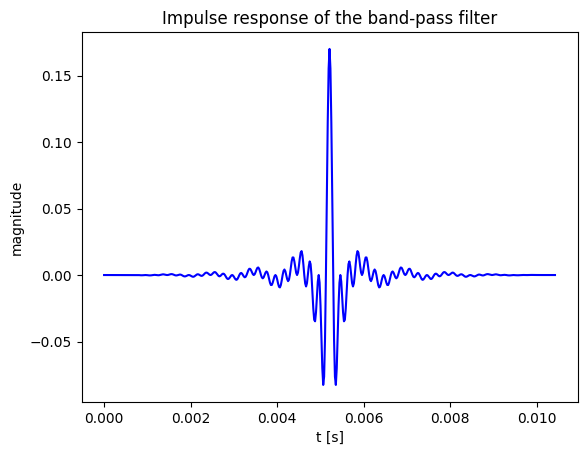

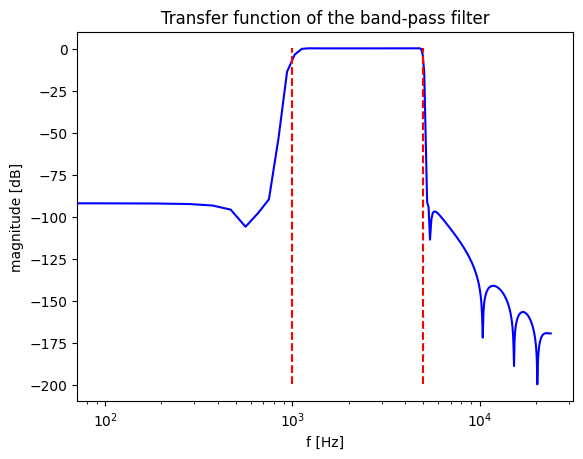

In [4]:
def ApplyFCenter(h, f_center, r):
    t = np.arange(h.shape[0]) / r
    t -= np.mean(t)
    return h * np.cos(2*np.pi*f_center*t)

def EvalImpulseResponseOFBandpassFilter(f_low, f_high, r, LengthOfFilterInSamples=501):
    assert f_high > f_low, 'lower frequency must be lower than higher frequency'
    assert f_high < r/2, 'violation of sampling theorem'
    h_LP = EvalImpulseResponseOfLowpassFilter((f_high - f_low)/2, r, LengthOfFilterInSamples)
    f_center = (f_low + f_high) / 2
    return 2*ApplyFCenter(h_LP, f_center, r)

LowerCutoffFrequencyInHertz = 1000
HigherCutoffFrequencyInHertz = 5000
h_BP = EvalImpulseResponseOFBandpassFilter(LowerCutoffFrequencyInHertz, HigherCutoffFrequencyInHertz, r, 51)
t = np.arange(h_BP.shape[0]) / r
plt.plot(t, h_BP, 'b')
plt.xlabel('t [s]')
plt.ylabel('magnitude')
plt.title('Impulse response of the band-pass filter')
plt.show()

FFTLength = 2**int(np.ceil(np.log2(h_BP.shape[0])))
H_BP = np.fft.rfft(h_BP, n = FFTLength)
f = np.arange(H_BP.shape[0]) / FFTLength * r
H_BP_dB = 20 * np.log10(np.abs(H_BP))
plt.semilogx(f, H_BP_dB, 'b')
plt.plot([LowerCutoffFrequencyInHertz, LowerCutoffFrequencyInHertz], [H_BP_dB.min(), H_BP_dB.max()], 'r--')
plt.plot([HigherCutoffFrequencyInHertz, HigherCutoffFrequencyInHertz], [H_BP_dB.min(), H_BP_dB.max()], 'r--')
plt.xlabel('f [Hz]')
plt.ylabel('magnitude [dB]')
plt.title('Transfer function of the band-pass filter')
plt.show()

## FIR: Highpass
Each lowpass filter with cutoff frequency $f_{c, LP}$ can be transformed into a highpass filter with cutoff frequency $f_{c, HP} = \frac{r}{2} - f_{c, LP}$:

$h_\text{highpass}(n)=h_\text{lowpass}(n) \cdot \left(-1\right)^n$

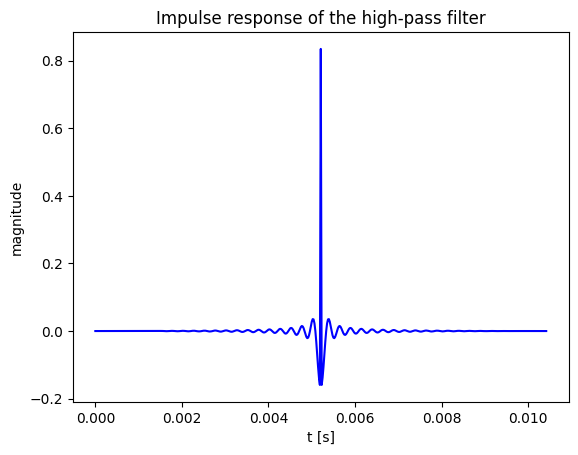

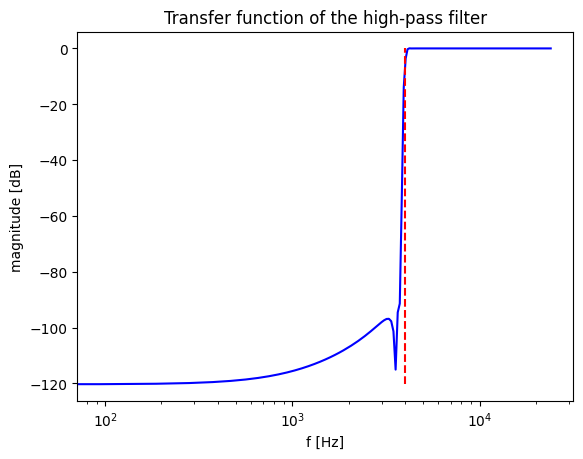

In [5]:
def EvalImpulseResponseOfHighpassFilter(fc, r, LengthOfFilterInSamples=501):
    assert fc < r/2, 'violation of sampling theorem'
    h_LP = EvalImpulseResponseOfLowpassFilter(r/2 - fc, r, LengthOfFilterInSamples)
    f_center = r/2
    return ApplyFCenter(h_LP, f_center, r)

CutoffFrequencyInHertz = 4000
h_HP = EvalImpulseResponseOfHighpassFilter(CutoffFrequencyInHertz, r, 51)
t = np.arange(h_HP.shape[0]) / r
plt.plot(t, h_HP, 'b')
plt.xlabel('t [s]')
plt.ylabel('magnitude')
plt.title('Impulse response of the high-pass filter')
plt.show()

FFTLength = 2**int(np.ceil(np.log2(h_BP.shape[0])))
H_HP = np.fft.rfft(h_HP, n = FFTLength)
f = np.arange(H_HP.shape[0]) / FFTLength * r
H_HP_dB = 20 * np.log10(np.abs(H_HP))
plt.semilogx(f, H_HP_dB, 'b')
plt.plot([CutoffFrequencyInHertz, CutoffFrequencyInHertz], [H_HP_dB.min(), H_HP_dB.max()], 'r--')
plt.xlabel('f [Hz]')
plt.ylabel('magnitude [dB]')
plt.title('Transfer function of the high-pass filter')
plt.show()

## FIR Application 1: Noisy sensor signals
A sensor records not only the wanted signal but also a lot of noise.
The simplest way to recude this noise is a bandpass-filter.
For applying a bandpass for noise reduction, you need to know the frequency range of the wanted signal $x(n)$ of your sensor.

In the following, the wanted signal $x(n)$ is a sweep ranging from low frequencies up to the highest frequencies. This signal should be a very simple model of human voice.

y(n) is the sensorsignal, which corresponds to the wanted signal plus additive white gaussian noise (AWGN).

In [6]:
f = np.arange(r)/r * 3000 + 100
t = np.arange(r)/r
x = np.sin(2*np.pi*f*t)
y = x + 0.2*np.random.randn(x.shape[0])
SNR = 10*np.log10(np.sum(x**2) / np.sum((x-y)**2))
print('SNR of the sensor: ', SNR, ' dB')

SNR of the sensor:  10.912361962530879  dB


## FIR Application 1: Denoising by bandpass-filtering

In the following, a bandpass is defined, which let  the most significant parts of voice (wideband voice) pass. This bandpass introduces a delay $D$ and a change $a$ regarding the amplitude:

$z(n)=a\cdot y(n-D)$

The delay $D$ of a symmetric filter of length $N$ is half of the length of the filter: $D=\frac{N}{2}$ .
A FIR filter is symmetric, if the following is true for every $n$: $h(n) = h(N-1-n)$.

The best estimate for the change in amplitude is evaluated by minimizing the squared error (and thus maximizing the [SNR](../Basics/SignalToNoiseRatio.ipynb)):

minimize regarding to the parameter $a$: $\sum_n \left(a\cdot y(n-D) - z(n)\right)^2$

The minimum is found for:

$a=\frac{\sum_n y\left(n-D\right)\cdot z(n)}{\sum_n y(n-D)^2}$

delay due to filtering in samples: D =  250
gain due to filtering =  0.9560489653740083
SNR before the bandpass:  10.912361962530879  dB
SNR after the bandpass:  15.253726733223596  dB


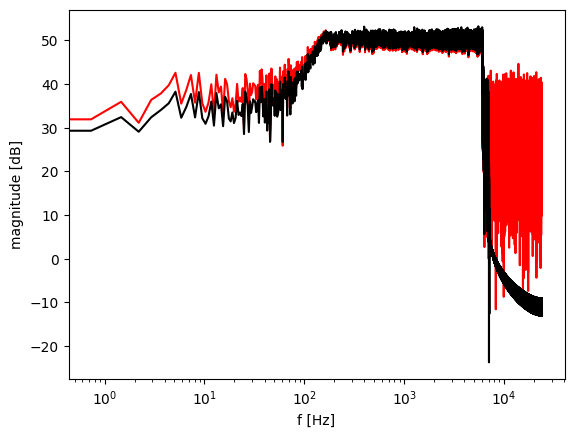

In [7]:
LowerCutoffFrequencyInHertz = 50
UpperCutoffFrequencyInHertz = 7000
N = 501
h_BP = EvalImpulseResponseOFBandpassFilter(LowerCutoffFrequencyInHertz, UpperCutoffFrequencyInHertz, r, LengthOfFilterInSamples=N)
for n in range(N):
    assert np.abs(h_BP[n] - h_BP[N-1-n]) < 1e-6, 'the impulse response of the band-pass filter should be symmetric'
z = np.convolve(y, h_BP)
D = h_BP.shape[0] // 2
print('delay due to filtering in samples: D = ', D)
z = z[D:x.shape[0]+D]
a = np.sum(y*z) / np.sum(y**2)
print('gain due to filtering = ', a)
z /= a
SNR = 10*np.log10(np.sum(x**2) / np.sum((x - y)**2))
print('SNR before the bandpass: ', SNR, ' dB')
SNR = 10*np.log10(np.sum(x**2) / np.sum((x - z)**2))
print('SNR after the bandpass: ', SNR, ' dB')


FFTLength = 2**int(np.ceil(np.log2(y.shape[0])))
Y = np.fft.rfft(y, n=FFTLength)
Z = np.fft.rfft(z, n=FFTLength)
Y_dB = 20 * np.log10(np.abs(Y))
Z_dB = 20 * np.log10(np.abs(Z))
f = np.arange(Y.shape[0]) / FFTLength * r
plt.semilogx(f, Y_dB, 'r') # noisy signal
plt.semilogx(f, Z_dB, 'k') # denoised signal after the bandpass
plt.xlabel('f [Hz]')
plt.ylabel('magnitude [dB]')
plt.show()

## FIR Application 2: Frequency range of human voice

Human voice can typically be recorded in three different modes:

Narrowband corresponds to a frequency range of $300 \text{ Hz}<f<3400\text{ Hz}$.

Wideband corresponds to a frequency range of $50 \text{ Hz}<f<7000\text{ Hz}$.

Fullband corresponds to a frequency range of $20 \text{ Hz}<f<20000\text{ Hz}$.

Listen to the output and rate the signals Narrowband, Wideband and Fullband regarding their quality.

In [8]:
x, r = WaveFileHandling.ReadWaveAsNumpyArray('../Audio/P501_D_EN_fm_SWB_48k.wav')
print('sampling rate: r=', r)

def ApplyBandpass(x, r, fc1, fc2):
    h_BP = EvalImpulseResponseOFBandpassFilter(fc1, fc2, r)
    y = np.convolve(x, h_BP)
    y /= np.amax(np.abs(y))
    return y

y_NB = ApplyBandpass(x, r, 300, 3400)
WaveFileHandling.WriteWaveAsNumpyArray(y_NB, r, 'Narrowband.wav')
y_WB = ApplyBandpass(x, r, 50, 7000)
WaveFileHandling.WriteWaveAsNumpyArray(y_WB, r, 'Wideband.wav')
y_FB = ApplyBandpass(x, r, 20, 20000)
WaveFileHandling.WriteWaveAsNumpyArray(y_FB, r, 'Fullband.wav')

sampling rate: r= 48000


## Infinite Impulse Response Filter
Infinite impulse response filters (IIR) are defined by the difference equation:

$y(n) = \sum_{k=0}^K b_k\cdot x(n-k)-\sum_{l=1}^L a_l\cdot y(n-l)$

For evaluating the output $y(n)$ of an IIR filter, only $K + 1 + L$ multiplications and additions are necessary. The order of the IIR filter is usually much smaller than the length of a FIR filter. Therefore, the evaluation is usually much faster, than for a FIR filter.

In [9]:
from scipy.signal import lfilter, butter, ellip

### this filter simulates the outer ear transfer function (Vary, Digitale Sprachsignalverarbeitung, page 517)
a = np.array([1, 0.797, -0.161, -0.281, -0.111])
b = np.array([1.378, 0.574, -0.512, -0.129, -0.065])

x = np.random.randn(10000)

t0 = time.time()
y1 = np.zeros(x.shape)
for n in range(x.shape[0]):
    for k in range(b.shape[0]):
        if n-k >= 0:
            y1[n] += b[k] * x[n-k]
    for l in range(1, a.shape[0]):
        if n-l >= 0:
            y1[n] -= a[l] * y1[n-l]

t1 = time.time()

y2 = lfilter(b, a, x)

t2 = time.time()

print('slow evaluation time: ', t1 - t0, ' s')
print('fast evaluation time: ', t2 - t1, ' s')
assert np.sum((y1-y2)**2) < 1e-10, 'error in IIR evaluation'

ModuleNotFoundError: No module named 'scipy'

## IIR: z-Transform of the differential equation
The corresponding [z-transform](../Basics/zTransform.ipynb) of the differential equation is given by:

$Y(z) = \sum_{k=0}^K b_k\cdot z^{-k}\cdot X(z)-\sum_{l=1}^L a_l\cdot z^{-l}Y(z)$

The transfer function is defined by:

$H(z)=\frac{Y(z)}{X(z)}=\frac{\sum_{k=0}^K b_k\cdot z^{-k}}{1+\sum_{l=1}^L a_l\cdot z^{-l}}$

The transfer function in frequency domain is found by the following replacement:

$z\rightarrow e^{j2\pi f / r}$

$H(f)=\frac{\sum_{k=0}^K b_k\cdot e^{-j2\pi f k/r}}{1+\sum_{l=1}^L a_l\cdot e^{-j2\pi f l/r}}$

In the following example the filters transfer function is evaluated. It can be seen, that the maximum of the transfer function is roughly at $3$ kHz with decreasing slopes for higher and lower frequencies. By this, the given filter is classified as a bandpass.

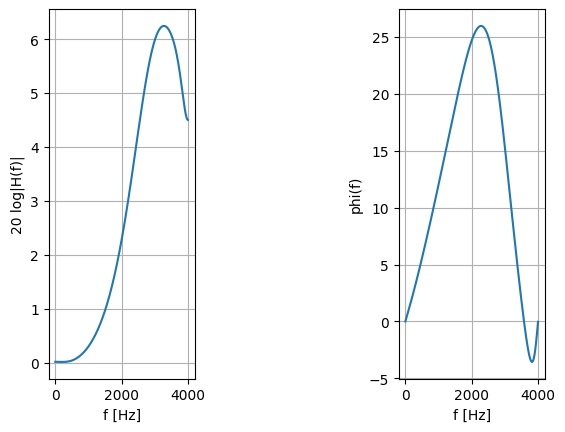

In [ ]:
def Transferfunction(a, b, z):    
    N = 0
    D = 1
    for k in range(b.shape[0]):
        N += b[k] * (z**(-k))
    for l in range(1, a.shape[0]):
        D += a[l] * (z**(-l))
    H = N / D
    return H

def BodePlotIIRFilter(a, b, r):
    f = np.arange(r/2)
    z = np.exp(1j*2*np.pi*f/r)
    H = Transferfunction(a, b, z)
    plt.subplot(131)
    plt.plot(f, 20*np.log10(np.abs(H)))
    plt.ylabel('20 log|H(f)|')
    plt.xlabel('f [Hz]')
    plt.grid(which='both', axis='both')
    plt.subplot(133)
    plt.plot(f, np.angle(H, deg=True))
    plt.ylabel('phi(f)')
    plt.xlabel('f [Hz]')
    plt.grid(which='both', axis='both')
    plt.show()    

r = 8000
BodePlotIIRFilter(a, b, r)

## IIR: Stability, Poles, Zeros
An IIR filter is stable, if all poles of $H(z)$ are inside the unit circle:

$H(z)=\frac{\sum_{k=0}^K b_k\cdot z^{-k}}{1+\sum_{l=1}^L a_l\cdot z^{-l}}$

The zeros $z_{0,k}$ are evaluated by solving the following equation:

$\sum_{k=0}^K b_k\cdot z_{0,k}^{-k} = 0$

The poles $z_{p,l}$ are evaluated by solving the following equation:

$1+\sum_{l=1}^L a_l\cdot z_{p,l}^{-l} = 0$

The evaluated poles and zeros are usually plotted in a pole zero diagram of the complex plain, as shown below.

IIR filter is stable:  True


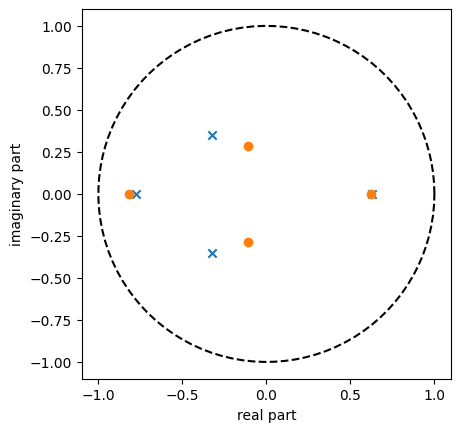

In [ ]:
def IsStableIIRFilter(a, b):
    DenominatorRoots = np.roots(a)
    return np.amax(np.abs(DenominatorRoots)) < 1.0

def PlotZerosPolesIIRFilter(a, b):
    NumeratorRoots = np.roots(b)
    DenominatorRoots = np.roots(a)
    phi = np.arange(100) / 99 * 2 * np.pi
    plt.plot(np.cos(phi), np.sin(phi), '--k') # plot the unit circle
    plt.scatter(DenominatorRoots.real, DenominatorRoots.imag, marker = 'x') # plot the roots
    plt.scatter(NumeratorRoots.real, NumeratorRoots.imag, marker = 'o') # plot the zeros
    plt.xlabel('real part')
    plt.ylabel('imaginary part')
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.show()

print('IIR filter is stable: ', IsStableIIRFilter(a, b))
PlotZerosPolesIIRFilter(a, b)

## IIR: Surface plot of transfer function
When the transfer function is plotted as a surface in the z-domain, the poles and zeros can be interpreted as support points of a tent. The poles corresponds in this metapher to tent poles. The zeros are the points, where the tent touches ground. The transfer function in frequency domain is the magnitude at the position of the unit circle.

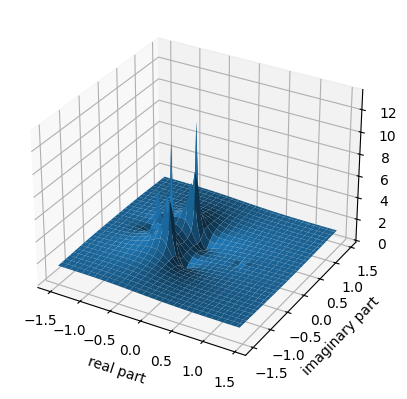

In [ ]:
def TransferFunctionSurface(x, y):
    z = x + 1j*y
    return np.abs(Transferfunction(a, b, z))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x = y = np.arange(-1.5, 1.5, 0.05)
X, Y = np.meshgrid(x, y)
zs = np.array(TransferFunctionSurface(np.ravel(X), np.ravel(Y)))
Z = zs.reshape(X.shape)

ax.plot_surface(X, Y, Z)

ax.set_xlabel('real part')
ax.set_ylabel('imaginary part')
ax.set_zlabel('magnitude')

plt.show()

## Programming exercise:

The cutoff frequency $f_c$ of a lowpass $X(f)$ is defined by:

$\frac{\left|H\left(f_c\right)\right|}{\left|H\right|_\text{max}}=\frac{1}{\sqrt{2}}$ (1)

In [decibel](../Basics/Decibel.ipynb) this corresponds to:

$20\log_{10}\frac{1}{\sqrt{2}}=-3.01$ dB

A bandpass has two cutoff frequencies, which marks the passband. For simplicity, the cutoff frequencies of a bandpass are defined as follows:

The lower cutoff frequency is the lowest frequency for which condition (1) is true.

The higher cutoff frequency is the highest frequency for which condition (1) is true.

1) Write a procedure EvaluateMagnitudeSpectrum, which evaluates the transfer function out of an impulse response.

2) Write a procedure EvaluateCutoffFrequencies, which evaluates the cutoff frequencies for a time discrete FIR bandpass given in time domain. For this, use the [DFT](../Week03_DiscreteFourierTransform/01_DiscreteFourierTransform.ipynb) in order to evaluate the cutoff frequencies with an accuracy of $20$ Hz.


The following equation for an IIR filter is given: $y(n) = a\cdot y(n-1) + (1-a)\cdot x(n)$ with $3-\sqrt{8}<|a|<1$

3) Write the code for the procedure TransferFunction to evaluate the corresponding transfer function $H(f)$.

4) Write the code for the procedure CheckInput1, which checks the conditions for parameter $a$.

5) Write the code for the procedure DampingParameter2CutoffFrequency to evaluate the cutoff frequency depending on the damping parameter $a$. Hint: the given equation is a lowpass filter with highest magnitude at $f=0$ Hz.

6) Write the code for the procedure CheckInput2, which checks the conditions of the cutoff frequency and the sampling rate.

7) Write the code for the procedure CutoffFrequency2DampingParameter to evaluate the parameter $a$ depending on the cutoff frequency.

In [ ]:
def EvaluateMagnitudeSpectrum(h, r, MaximumDeltaf):
    ### solution begins

    ### solution ends
    return H, f

def EvaluateCutoffFrequencies(h_Bandpass, r):
    ### solution begins

    ### solution ends
    return fc1, fc2

def TransferFunction(f, r, a):
    H = 1
    ### solution

    ### solution
    return H

def CheckInput1(a):
    ### solution

    ### solution

def DampingParameter2CutoffFrequency(a, r):
    CheckInput1(a)
    ### solution

    ### solution
    return fc

def CheckInput2(fc, r):
    ### solution

    ### solution


def CutoffFrequency2DampingParameter(fc, r):
    CheckInput2(fc, r)
    a = 0
    ### solution

    ### solution
    return a

import unittest

class TestProgrammingExercise(unittest.TestCase):

    def test_EvaluateDFT_Shape(self):
        r = 16000
        MaximumDeltaf = np.random.rand(1)*100
        MaximumDeltaf = MaximumDeltaf[0]
        h = np.array([1, -2, 1])
        H, f = EvaluateMagnitudeSpectrum(h, r, MaximumDeltaf)
        self.assertEqual(H.shape, f.shape)

    def test_EvaluateDFT_LinearityOfFrequencyAxis(self):
        r = 16000
        MaximumDeltaf = np.random.rand(1)*100
        MaximumDeltaf = MaximumDeltaf[0]
        h = np.array([1, -2, 1])
        H, f = EvaluateMagnitudeSpectrum(h, r, MaximumDeltaf)
        self.assertLessEqual(np.std(np.diff(f)), 1e-6) # check linearity of frequency axis

    def test_EvaluateDFT_ConditionDeltaf(self):
        r = 16000
        MaximumDeltaf = np.random.rand(1)*100
        MaximumDeltaf = MaximumDeltaf[0]
        h = np.array([1, -2, 1])
        H, f = EvaluateMagnitudeSpectrum(h, r, MaximumDeltaf)
        self.assertLessEqual(np.mean(np.diff(f)), MaximumDeltaf)

    def test_EvaluateDFT_MonotonicityOfFrequencyAxis(self):
        r = 16000
        MaximumDeltaf = np.random.rand(1)*100
        MaximumDeltaf = MaximumDeltaf[0]
        h = np.array([1, -2, 1])
        H, f = EvaluateMagnitudeSpectrum(h, r, MaximumDeltaf)
        self.assertGreater(np.min(np.diff(f)), 0.0) # check monotonicity of frequency axis
        self.assertGreater(np.min(np.diff(H)), 0.0) # check monotonicity of magnitude spectrum of a low-pass filter
        self.assertGreater(np.max(np.diff(H)), 0.0) # check monotonicity of magnitude spectrum of a low-pass filter

    def test_EvaluateDFT_MonotonicityOfTransferFunction(self):
        r = 16000
        MaximumDeltaf = np.random.rand(1)*100
        MaximumDeltaf = MaximumDeltaf[0]
        h = np.array([1, -2, 1])
        H, f = EvaluateMagnitudeSpectrum(h, r, MaximumDeltaf)
        self.assertGreater(np.min(np.diff(H)), 0.0) # check monotonicity of magnitude spectrum of a low-pass filter
        self.assertGreater(np.max(np.diff(H)), 0.0) # check monotonicity of magnitude spectrum of a low-pass filter
    
    def test_RandomBandpasses(self):
        r = 16000
        for n in range(10):
            fc1 = np.random.rand(1) * r/8 + r/8
            fc2 = r/2 - (np.random.rand(1) * r/8 + r/8)
            h_Bandpass = EvalImpulseResponseOFBandpassFilter(fc1, fc2, r, LengthOfFilterInSamples=5001)
            fc1_est, fc2_est = EvaluateCutoffFrequencies(h_Bandpass, r)
            self.assertAlmostEqual(fc1_est, fc1, delta = 20.0)
            self.assertAlmostEqual(fc2_est, fc2, delta = 20.0)

    def test_CheckInput1(self):
        UpperLimit = 1.0
        LowerLimit = 3-np.sqrt(8)
        a = np.random.randn(1)**2 + UpperLimit
        self.assertRaises(AssertionError, CheckInput1, a)
        a = LowerLimit - np.random.randn(1)**2
        self.assertRaises(AssertionError, CheckInput1, a)
        self.assertRaises(AssertionError, CheckInput1, UpperLimit)
        self.assertRaises(AssertionError, CheckInput1, LowerLimit)

    def test_CheckInput2(self):
        r = 16000
        fc = np.random.rand(1)*2*r-r
        if (fc <= 0.0) or (2*fc >= r):
            self.assertRaises(AssertionError, CheckInput2, fc, r)

    def test_TransferFunction(self):
        f = 1500
        r = 16000
        a = 0.75
        self.assertAlmostEqual(0.2984-0.3304j, TransferFunction(f, r, a), delta = 1e-1)
        f = 12000
        r = 32000
        a = 0.9        
        self.assertAlmostEqual(0.05308-0.02064j, TransferFunction(f, r, a), delta = 1e-1)
        f = 12000
        r = 32000
        a = -0.9        
        self.assertAlmostEqual(1.286+2.2508j, TransferFunction(f, r, a), delta = 1e-1)

    def test_DampingParameter(self):
        for r in [16000, 32000, 44100]:
            a = 0.9
            fc = DampingParameter2CutoffFrequency(a, r)
            self.assertAlmostEqual(fc, r*0.016784, delta = 1e-2)
            a = 0.7
            fc = DampingParameter2CutoffFrequency(a, r)
            self.assertAlmostEqual(fc, r*0.057378, delta = 1e-2)

    def test_CutoffFrequency1(self):
        r = 44100
        fc = r/5
        a = CutoffFrequency2DampingParameter(fc, r)
        self.assertAlmostEqual(a, 0.32737619817917585, delta = 1e-7)
        r = 16000
        fc = r/7
        a = CutoffFrequency2DampingParameter(fc, r)
        self.assertAlmostEqual(a, 0.4305819103800278, delta = 1e-7)
    
    def test_CutoffFrequency2(self):
        r = 16000
        x = 2/3
        for n in range(100):
            x = (x-x**2)*4
            assert x > 0.0, 'input too small'
            assert x < 1.0, 'input too large'
            fc = x*r/2        
            a = CutoffFrequency2DampingParameter(fc, r)
            self.assertAlmostEqual(np.abs(TransferFunction(fc, r, a)), 1/np.sqrt(2), delta = 1e-2)
            self.assertGreater(np.abs(TransferFunction((0 + fc) * 0.5, r, a)), 1/np.sqrt(2))
            self.assertLess(np.abs(TransferFunction((r/2 + fc) * 0.5, r, a)), 1/np.sqrt(2))

    def test_RandomInversion(self):
        r = 48000
        x = 2/3
        for n in range(100):
            x = (x-x**2)*4
            assert x > 0.0, 'input too small'
            assert x < 1.0, 'input too large'
            fc = x*r/2
            a = CutoffFrequency2DampingParameter(fc, r)
            self.assertAlmostEqual(fc, DampingParameter2CutoffFrequency(a, r), delta = 1e-1)
    
# https://stackoverflow.com/questions/40172281/unit-tests-for-functions-in-a-jupyter-notebook
unittest.main(argv=[''], verbosity=2, exit=False)

test_CheckInput1 (__main__.TestProgrammingExercise.test_CheckInput1) ... ok
test_CheckInput2 (__main__.TestProgrammingExercise.test_CheckInput2) ... ok
test_CutoffFrequency1 (__main__.TestProgrammingExercise.test_CutoffFrequency1) ... ok
test_CutoffFrequency2 (__main__.TestProgrammingExercise.test_CutoffFrequency2) ... ok
test_DampingParameter (__main__.TestProgrammingExercise.test_DampingParameter) ... ok
test_EvaluateDFT_ConditionDeltaf (__main__.TestProgrammingExercise.test_EvaluateDFT_ConditionDeltaf) ... ok
test_EvaluateDFT_LinearityOfFrequencyAxis (__main__.TestProgrammingExercise.test_EvaluateDFT_LinearityOfFrequencyAxis) ... ok
test_EvaluateDFT_MonotonicityOfFrequencyAxis (__main__.TestProgrammingExercise.test_EvaluateDFT_MonotonicityOfFrequencyAxis) ... ok
test_EvaluateDFT_MonotonicityOfTransferFunction (__main__.TestProgrammingExercise.test_EvaluateDFT_MonotonicityOfTransferFunction) ... ok
test_EvaluateDFT_Shape (__main__.TestProgrammingExercise.test_EvaluateDFT_Shape) ... o

## Exam preparation

1) Evaluate the [z-transform](../Basics/zTransform.ipynb) of a filter $h(n)=[1, 2, 1]$. Is this filter a lowpass, a bandpass or a highpass? Hint: For simpler evaluation $r=1$ is assumed.

2) Convert the FIR filter $h(n)=[1, 2, 1]$ into a highpass.

3) Evaluate the convolution of $x(n) = [0, 1, 2]$ with $h(n)=[1, 2, 1]$.

4) Evaluate the samples of the impulse response of a FIR lowpass filter of length $N=5$ for a sampling rate of $r=1000$ Hz and a cutoff frequency of $f_c = 250$ Hz.

5) How many multiplications and additions are necessary to evaluate a single output sample of a FIR filter with length $N=501$ samples.

6) Show that $a=\frac{\sum_n y\left(n-T\right)\cdot z(n)}{\sum_n y(n-T)^2}$ minimizes $\sum_n \left(a\cdot y(n-T) - z(n)\right)^2$ .

7) White background noise has roughly a constant power density spectrum $\left|R(f)\right|^2\approx \text{const}$. Evaluate the increase in SNR by using an ideal FIR bandpass with cut off frequencies $f_{c1}=100$ Hz and $f_{c2}=7000$ Hz, assuming, that the human voice can pass this filter without any decrease in quality. The sampling rate is assumed to be $r=48$ kHz.

8) A FIR lowpass is given: $h(n)=[a,1,a]$ with $a$ being real valued. For which $a$, the following condition is true? $\left|H(f)\right| > 0$

9) An FIR filter is given: $ℎ(𝑛)=[-1, 1]$. Is $ℎ(𝑛)$ stable? (Give a reason for your answer) Evaluate the real part of the transfer function $𝐻(𝑓)$ of $ℎ(𝑛)$. Is the real part positive for any $𝑓$?

10) A lowpass is given by $h(n)=[1, 4, 6, 4, 1]$. The sampling rate is $r=48$ kHz. Evaluate the impulse response of the corresponding bandpass with $f_m=12$ kHz.

11) For which $a$ is the following equation $y(n) = a\cdot y(n-1) + (1-a)\cdot x(n)$ stable?

12) Evaluate the cutoff frequency $f_c$ of the IIR filter given in 11) depending on the damping parameter $a$.

13) The filter of 11) has the impulse response $h(n) = (1-a) \cdot a^n$. Evaluate the smallest possible $n_0$ for which the following statement is valid: $h(n_0) < h(n=0)\cdot e^{-5}$. This $n_0$ can be interpreted as the reasonable length of the impulse response. For $n > n_0$, the impulse response can be interpreted as stationary.

14) An audio interface has a sampling rate of $r=48$ kHz. For denoising purposes, the signal is filtered by a bandpass with cutoff frequencies $f_{c,1}=100$ Hz and $f_{c,2}=7$ kHz. Has the audio signal a zero mean after the filter? Is human speech capable of passing this filter? Would this filter suppress hum noise at $50$ Hz?

15) Evaluate the poles and zeros of $H(z)=\frac{z^2-4z-7}{z^2-9}$.

## Summary
After working with this Jupyter Notebook you should be able to explain the following topics:

- What is the equation for evaluating the output of a FIR filter?
- How can you check, if a filter is a lowpass, a bandpass oder a highpass?
- What is the motivation for applying a bandpass on the sensors output?
- How can you evaluate the delay of a symmetric FIR filter?
- How can you check, if a FIR filter is symmetric?
- How can you evaluate the gain of a filter?
- What is the frequency range for human speech?
- How can you transform a lowpass into a bandpass or into a highpass?
- What is the relationship between differential equation and transfer function of an IIR filter?
- What is the relationship between the z-transform and the Fourier-transform for an IIR filter?
- How can you evaluate the pole-zero-plot?
- Under which circumstances is an IIR filter stable?